# Accessible PlantUML State Diagrams

This notebook demonstrates how to create an accessibility-aware state diagram in PlantUML from Python.

## What this diagram is used for

State diagrams represent changes between system states triggered by events. They are useful in software, embedded systems, networking, and other state-based processes.

## How to make it more accessible

Clearly define each state, describe every triggering event explicitly, and avoid overly dense transition networks. The accompanying text should describe the initial state and each important transition in a logical order.

## Setup

These notebooks use **Python to write PlantUML source code and call PlantUML locally** to render the diagram.

PlantUML must therefore be available on your system. A local PlantUML installation requires Java, and some diagram types may also require Graphviz.

You can use PlantUML in either of these ways:

1. **Install the PlantUML command-line tool** using the package manager available on your operating system.
2. **Download `plantuml.jar`** from the PlantUML website and run it with Java.

After installation, verify that PlantUML is available by running:

```bash
plantuml -version
```

If you use a downloaded `plantuml.jar` instead of a `plantuml` command, set the `PLANTUML_JAR` environment variable to the path of the JAR file before running the notebook.

The Python helper below supports both approaches.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess

from IPython.display import Image, display


def render_plantuml(source, filename):
    """Save PlantUML source, render it as PNG, and display it."""
    source_path = Path(f"{filename}.puml")
    source_path.write_text(source, encoding="utf-8")

    plantuml_executable = shutil.which("plantuml")
    plantuml_jar = os.environ.get("PLANTUML_JAR")

    if plantuml_executable:
        command = [
            plantuml_executable,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    elif plantuml_jar:
        command = [
            "java",
            "-jar",
            plantuml_jar,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    else:
        raise RuntimeError(
            "PlantUML was not found. Install the 'plantuml' command "
            "or set PLANTUML_JAR to the path of plantuml.jar."
        )

    result = subprocess.run(command, capture_output=True, text=True)

    if result.returncode != 0:
        raise RuntimeError("PlantUML rendering failed:\n" + result.stderr)

    image_path = source_path.with_suffix(".png")
    if not image_path.exists():
        raise FileNotFoundError(f"Rendered image was not created: {image_path}")

    display(Image(filename=str(image_path)))
    return image_path


## Accessible example

The example below creates an accessibility-aware state diagram also presented in the Guidelines document.

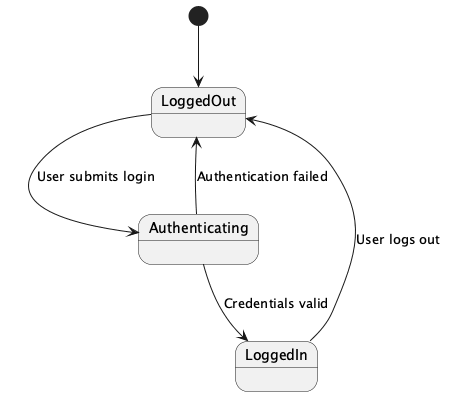

PosixPath('accessible_state_diagram.png')

In [ ]:
state_source = """@startuml
skinparam dpi 300
[*] --> LoggedOut
LoggedOut --> Authenticating : User submits login
Authenticating --> LoggedIn : Credentials valid
Authenticating --> LoggedOut : Authentication failed
LoggedIn --> LoggedOut : User logs out
@enduml
"""

render_plantuml(state_source, "accessible_state_diagram")

## Accessible description

State diagram for user authentication. The system starts in LoggedOut. When the user submits a login, it moves to Authenticating. Valid credentials move the system to LoggedIn, while failed authentication returns it to LoggedOut. When a logged-in user logs out, the system returns to LoggedOut.

## Reusable accessible template

Replace the state and event names with meaningful states and explicit transition triggers from your own system.

In [ ]:
state_template = """@startuml
[*] --> InitialState

InitialState --> ProcessingState : Describe triggering event
ProcessingState --> SuccessState : Describe success condition
ProcessingState --> InitialState : Describe failure condition
SuccessState --> InitialState : Describe reset or exit event
@enduml
"""

render_plantuml(state_template, "state_diagram_template")

## Accessible description template

After replacing the placeholder source with your own state diagram, add a concise textual description that:

- identifies the diagram type and purpose,
- names the important entities, classes, actions, states, or nodes,
- explains the relationships or interaction order,
- describes decision or transition logic where relevant,
- and states the key structural takeaway.

Do not rely on spatial wording alone. The description should communicate the important relationships encoded by the diagram.
